# Student Exam Performance Prediction - Regressão Logística - 2 classes

## Objetivos

Este notebook ilustra o problema de classificação.

O objetivo é classificar as amostras da Íris em 3 classes.
- o alvo é o índice da classe: 0, 1 ou 2
- função de perda é Entropia Cruzada
- rede é uma camada densa linear com duas entradas e três saídas (n. de classes)

## Importação das bibliotecas

In [1]:
%matplotlib inline
import os
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

from IPython import display

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "student_exam_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mrsimple07/student-exam-performance-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_37673/963526433.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-exam-performance-prediction' dataset.
First 5 records:    Study Hours  Previous Exam Score  Pass/Fail
0     4.370861            81.889703          0
1     9.556429            72.165782          1
2     7.587945            58.571657          0
3     6.387926            88.827701          1
4     2.404168            81.083870          0


## Dataset: Leitura, normalização e visualização dos dados

In [3]:
X = df[['Study Hours', 'Previous Exam Score']]
Xc = X - X.min(axis=0)
Xs = Xc.max(axis=0)
Xc = Xc/Xs
Xc

,Study Hours,Previous Exam Score
0,0.374003,0.696955
1,0.957232,0.534089
2,0.735834,0.306401
3,0.600865,0.813159
4,0.152806,0.683458
...,...,...
495,0.352555,0.087379
496,0.585679,0.917189
497,0.073563,0.132839
498,0.981203,0.950275


In [4]:
Y = df[['Pass/Fail']]
Y

,Pass/Fail
0,0
1,1
2,0
3,1
4,0
...,...
495,0
496,1
497,0
498,1


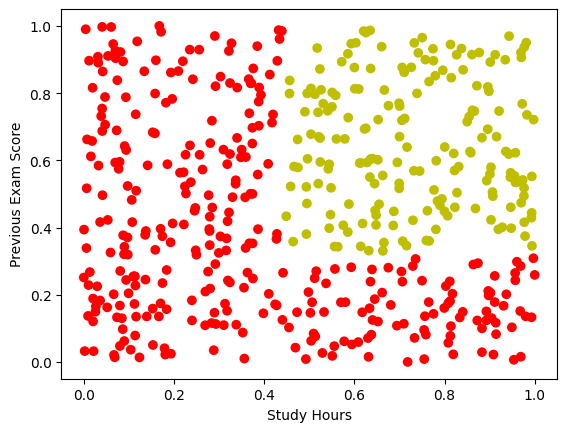

In [5]:
Y = Y.to_numpy().flatten()
colors = np.array(['r','y','b'])
plt.scatter(Xc.iloc[:, 0], Xc.iloc[:, 1], c=colors[Y])
plt.xlabel('Study Hours')
plt.ylabel('Previous Exam Score')
plt.show()

### Prepara os dados para o PyTorch

In [6]:
Xc = Xc.to_numpy()
X_tensor = torch.FloatTensor(Xc)  # Entrada é FloatTensor
Y_tensor = torch.LongTensor(Y)    # Classe é LongTensor

In [7]:
Y_tensor

tensor([0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
        1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,

## Construindo o modelo da rede

In [8]:
model = nn.Linear(2,2)  # 2 entradas e 2 saídas

In [9]:
model.state_dict()

OrderedDict([('weight',
              tensor([[ 0.2207,  0.5496],
                      [-0.5957, -0.3944]])),
             ('bias', tensor([0.0296, 0.4753]))])

### Fazendo um predict

In [10]:
out = model(Variable(X_tensor[:4,:])) # 4 amostras
out

tensor([[ 0.4952, -0.0224],
        [ 0.5344, -0.3056],
        [ 0.3604, -0.0839],
        [ 0.6091, -0.2034]], grad_fn=<AddmmBackward0>)

In [11]:
oo = F.softmax(out,dim=1)
oo

tensor([[0.6266, 0.3734],
        [0.6985, 0.3015],
        [0.6093, 0.3907],
        [0.6926, 0.3074]], grad_fn=<SoftmaxBackward0>)

### Calculando as probabilidades com Softmax

- [Wikipedia:Softmax_function](https://en.wikipedia.org/wiki/Softmax_function)

In [12]:
F.softmax(out,dim=1)*100

tensor([[62.6580, 37.3420],
        [69.8461, 30.1539],
        [60.9278, 39.0722],
        [69.2640, 30.7360]], grad_fn=<MulBackward0>)

### Predição da classe

In [13]:
prob,y_pred = torch.max(F.softmax(out,dim=1),dim=1)
print(y_pred)
print(prob)

tensor([0, 0, 0, 0])
tensor([0.6266, 0.6985, 0.6093, 0.6926], grad_fn=<MaxBackward0>)


## Treinamento

### Classe para visualização dinâmica

In [14]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

def predict_prob(model, inputs):
    outputs = model(Variable(inputs))
    outputs = F.softmax(outputs,dim=1)
    predicts, _ = torch.max(outputs, 1)

    return predicts.data.numpy()

class MyPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(12, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 3, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.set_title('Perda x Época')
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 3, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Study Hours')
        self.ax2.set_ylabel('Previous Exam Score')
        self.ax2.set_title('Fronteiras de decisão')

        self.ax3 = self.fig.add_subplot(1, 3, 3)
        self.ax3.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax3.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax3.set_xlabel('Study Hours')
        self.ax3.set_ylabel('Previous Exam Score')
        self.ax3.set_title('Máxima probabilidade')

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                #Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
                Zc = predict(self.model,torch.FloatTensor(self.X_grid))
                Zc = Zc.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Zc, cmap=plt.cm.Paired)
                colors = np.array(['r','y'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k')

                Zp = predict_prob(self.model,torch.FloatTensor(self.X_grid))
                Zp = Zp.reshape(self.xx.shape)

                self.ax3.pcolormesh(self.xx, self.yy, Zp, cmap=plt.cm.magma)
                colors = np.array(['r','y'])
                self.ax3.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k')

                display.display(self.fig)
                display.clear_output(wait=True)

### Laço principal de treinamento da Regressão Logística por Softmax

In [15]:
model = nn.Sequential(
    nn.Linear(2,3),
    nn.ReLU(),
    nn.Linear(3,2),
    #nn.ReLU(),
    #nn.Linear(3,2)
)

In [16]:
lr = 0.05

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

Final loss: 0.03756318241357803


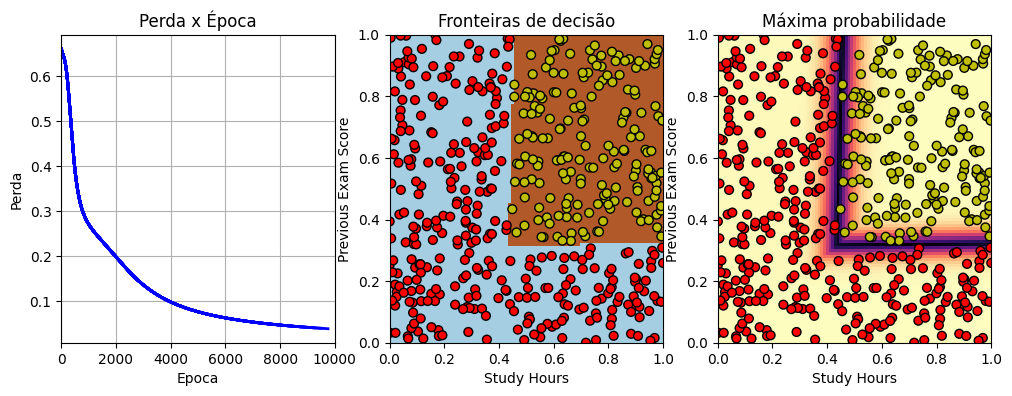

In [17]:
nb_epoch = 10000

#Definindo o plotter
my_plot = MyPlotter(model, Xc, Y, nb_epoch)

losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    # calcula a perda
    loss = criterion(output, Variable(Y_tensor))

    # Faz o backpropagation para calcular os gradientes e otimizar parâmetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data.item())

    my_plot.on_epoch_end(i, {'loss': loss.data.item()});
    final_loss = loss.data.item()

print('Final loss:', final_loss)

## Avaliação

### Parâmetros após treinamento

In [18]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0964, -0.6788],
                      [ 3.8495, -5.2759],
                      [ 4.8706, -0.1536]])),
             ('0.bias', tensor([-0.0445, -0.0103, -1.3087])),
             ('2.weight',
              tensor([[-0.0084,  4.3509, -3.4701],
                      [-0.4306, -4.8732,  3.6735]])),
             ('2.bias', tensor([ 2.9590, -2.4996]))])

### Salvando os parâmetros treinados

In [19]:
os.makedirs('../models',exist_ok=True)
torch.save(model.state_dict(),'../models/RegrLog_StudentPerformance.pt')

In [20]:
! ls ../models/

RegrLog_Iris.pt  RegrLog_StudentPerformance.pt


### Recuperando os pesos salvos

In [21]:
param_saved = torch.load('../models/RegrLog_StudentPerformance.pt')
model.load_state_dict(param_saved)
model.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0964, -0.6788],
                      [ 3.8495, -5.2759],
                      [ 4.8706, -0.1536]])),
             ('0.bias', tensor([-0.0445, -0.0103, -1.3087])),
             ('2.weight',
              tensor([[-0.0084,  4.3509, -3.4701],
                      [-0.4306, -4.8732,  3.6735]])),
             ('2.bias', tensor([ 2.9590, -2.4996]))])

### Exatidão (acurácia) do classificador

Acurácia indica o número de acertos sobre o número total de amostras

In [22]:
Y_pred = predict(model, X_tensor)
accuracy = (Y_pred == Y).mean()
print('Training Accuracy: ', accuracy)

Training Accuracy:  1.0


### Matriz de confusão

In [23]:
import pandas as pd
pd.crosstab(Y_pred, Y)

col_0,0,1
row_0,,
0,316,0
1,0,184
